##### **Data Dictionary**

* Date is presented in a format yyyy-mm-dd, and Location indicates Australian cities where the weather conditions were recorded.
* MinTemp and MaxTemp stand for minimum and maximum temperature for each day.
* Temp9am and Temp3pm stand for temperature(degrees Celsius) in the morning and in the evening repectively.
* Rainfall is measured in mm, and it is considered to be raining if the value of rainfall indicator is 1 mm or more.
* Evaporation is measured in mm.
* Sunshine stands for duration of bright sunshine in the 24 hours to midnight, measured in hours.
* WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm indicate direction (categorical value) and speed of wind (measured in km/h).
* Humidity9am, Humidity3pm indicates humidity, measured in percent.
Pressure9am, Pressure3pm indicate atmospheric pressure, measured in hectopascals.
* Cloud9am, Cloud3pm seem to indicate cloud level, measured as fraction of sky obscured by cloud.
* RainToday indicates whether it is rain today or not.
* RainTomorrow consists of target values.


##### **Importing Libraries and Loading Data**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

##### **Reading and Exploring Dataset**

In [2]:
data = pd.read_csv('weatherAUS.csv')
data.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [3]:
data.shape

(145460, 23)

In [4]:
data.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [5]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

##### **Data Visualization and Cleaning**

<Axes: xlabel='RainTomorrow', ylabel='count'>

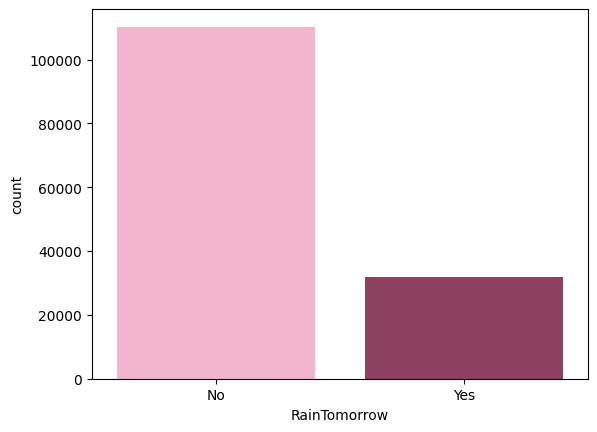

In [7]:
colours = ['#fea9cc','#98355e']
sns.countplot(x=data['RainTomorrow'], palette=colours)

###### **Analysing Categorical Variables**

In [8]:
#Listing categorical columns
obj = (data.dtypes == object)
cat_cols = list(obj[obj].index)
print("Categorical Columns : ",cat_cols)

Categorical Columns :  ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [9]:
#Finding missing values in categorical columns
for c in cat_cols:
  print(c, data[c].isnull().sum())

Date 0
Location 0
WindGustDir 10326
WindDir9am 10566
WindDir3pm 4228
RainToday 3261
RainTomorrow 3267


In [10]:
#Filling values with the mode value
for c in cat_cols:
  data[c].fillna(data[c].mode()[0], inplace= True)

In [11]:
for c in cat_cols:
  print(c, data[c].isnull().sum())

Date 0
Location 0
WindGustDir 0
WindDir9am 0
WindDir3pm 0
RainToday 0
RainTomorrow 0


##### **Exploring Numerical Variables**

In [12]:
#Listing numerical columns

n = (data.dtypes == "float64")
num_cols = list(n[n].index)
print("Numerical Columns : ",num_cols)

Numerical Columns :  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [13]:
#Finding missing values in numerical columns

for n in num_cols:
  print(n, data[n].isnull().sum())

MinTemp 1485
MaxTemp 1261
Rainfall 3261
Evaporation 62790
Sunshine 69835
WindGustSpeed 10263
WindSpeed9am 1767
WindSpeed3pm 3062
Humidity9am 2654
Humidity3pm 4507
Pressure9am 15065
Pressure3pm 15028
Cloud9am 55888
Cloud3pm 59358
Temp9am 1767
Temp3pm 3609


In [14]:
#Filling out with median value

for n in num_cols:
  data[n].fillna(data[n].median(), inplace = True)

In [15]:
data.isnull().sum().any

<bound method NDFrame._add_numeric_operations.<locals>.any of Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64>

In [16]:
#Parsing values into datetime
data['Date'] = pd.to_datetime(data['Date'])

#Creating columns for year, month and day
data['Year'] = data.Date.dt.year
data['Month'] = data.Date.dt.month
data['Day'] = data.Date.dt.day

data['Year']

0         2008
1         2008
2         2008
3         2008
4         2008
          ... 
145455    2017
145456    2017
145457    2017
145458    2017
145459    2017
Name: Year, Length: 145460, dtype: int64

**Visualizing the distribution of data and analyzing the correlation**

In [17]:
#data['Rainfall'] = data['Rainfall']/100

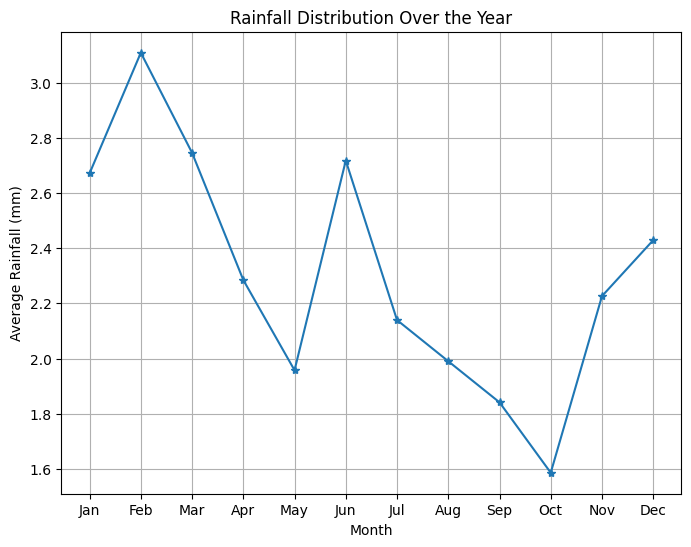

In [18]:
monthly_rainfall = data.groupby('Month')['Rainfall'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(8,6))
plt.plot(months,monthly_rainfall,marker='*',linestyle='-')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('Rainfall Distribution Over the Year')
plt.grid(True)
plt.show()

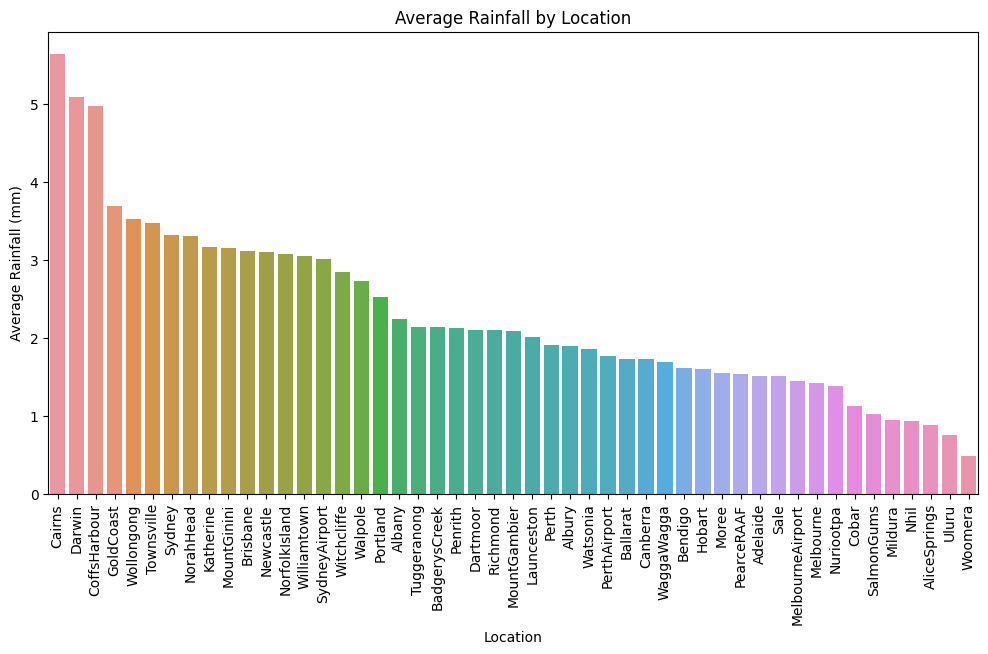

In [19]:
avg_rainfall_by_location = data.groupby('Location')['Rainfall'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rainfall_by_location.index, y=avg_rainfall_by_location.values)
plt.title('Average Rainfall by Location')
plt.xlabel('Location')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=90)
plt.show()


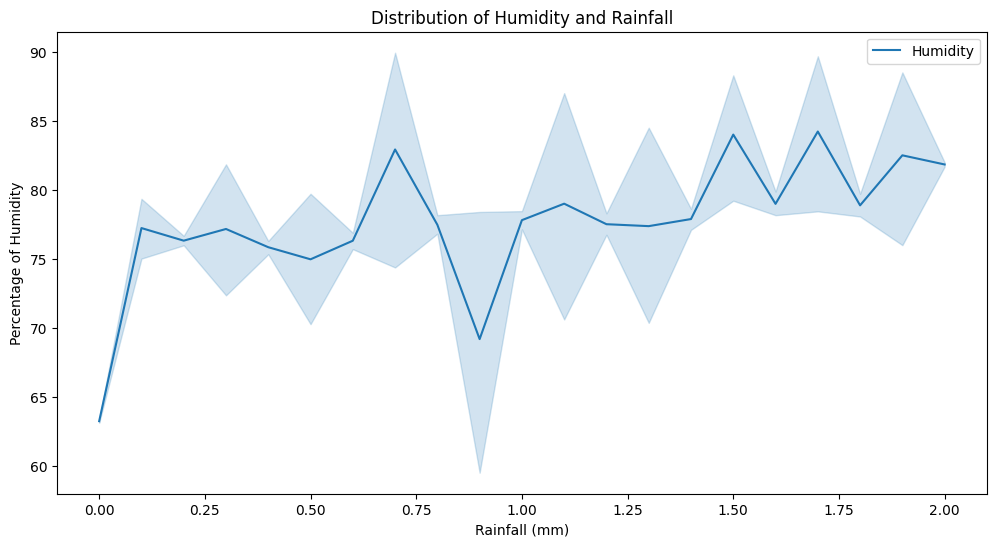

In [64]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Rainfall', y='Humidity9am', label='Humidity')
plt.title('Distribution of Humidity and Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Percentage of Humidity')
plt.legend()
plt.show()

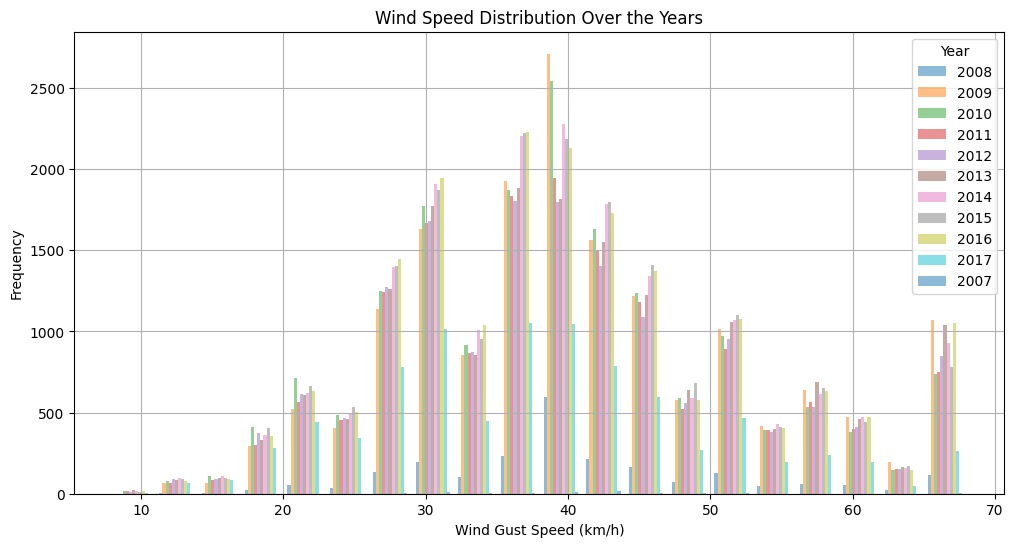

In [65]:
plt.figure(figsize=(12, 6))
plt.hist([data[data['Year']==year]['WindGustSpeed'] for year in data['Year'].unique()], bins=20, alpha=0.5, label=data['Year'].unique())
plt.xlabel('Wind Gust Speed (km/h)')
plt.ylabel('Frequency')
plt.title('Wind Speed Distribution Over the Years')
plt.legend(title='Year')
plt.grid(True)
plt.show()

#### **Preprocessing the Data**

In [22]:
le = LabelEncoder()
for c in cat_cols:
  data[c] = le.fit_transform(data[c])

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  int64  
 1   Location       145460 non-null  int64  
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  int64  
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  int64  
 10  WindDir3pm     145460 non-null  int64  
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

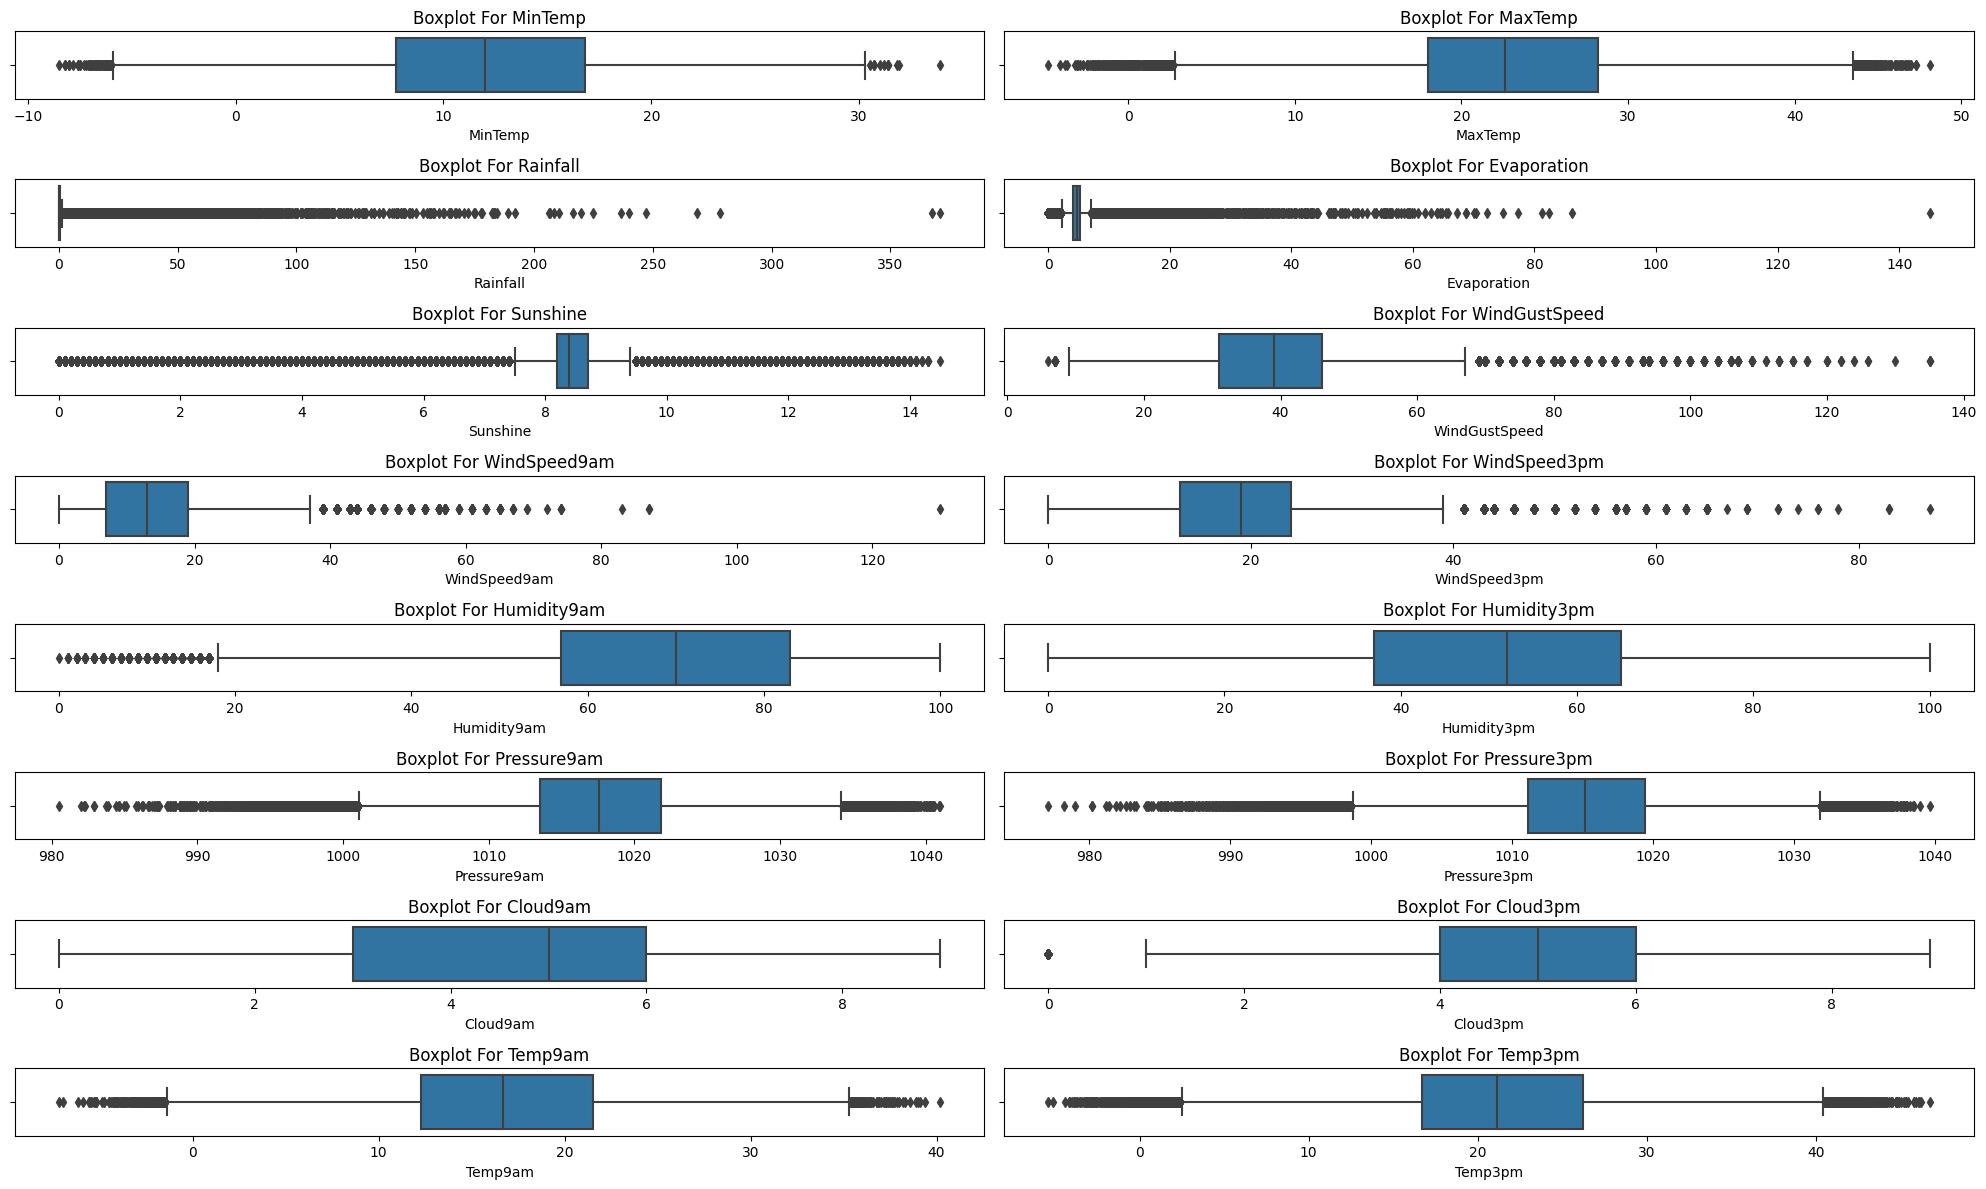

In [24]:
plt.figure(figsize=(20,12 ))
for n in num_cols:
  plt.subplot(8,2,num_cols.index(n)+1)
  sns.boxplot(x=n,data=data,hue='RainTomorrow')
  plt.title(f'Boxplot For {n}')
plt.tight_layout()
plt.show()

In [25]:
outlier_var = [n for n in num_cols if n not in ['Humidity3pm']]
print(outlier_var)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [26]:
def outlier_removal(df,outlier_var):
  df = data.copy()
  for variable in data[outlier_var].columns:
    q3 = data[variable].quantile(0.75)
    q1 = data[variable].quantile(0.25)
    iqr = q3 - q1
    upper_limit = round(q3+1.5*iqr)
    lower_limit = round(q1-1.5*iqr)
    data.loc[data[variable]>= upper_limit,variable] = upper_limit
    data.loc[data[variable]<=lower_limit,variable] = lower_limit
  return data


In [27]:
df = outlier_removal(data,outlier_var)

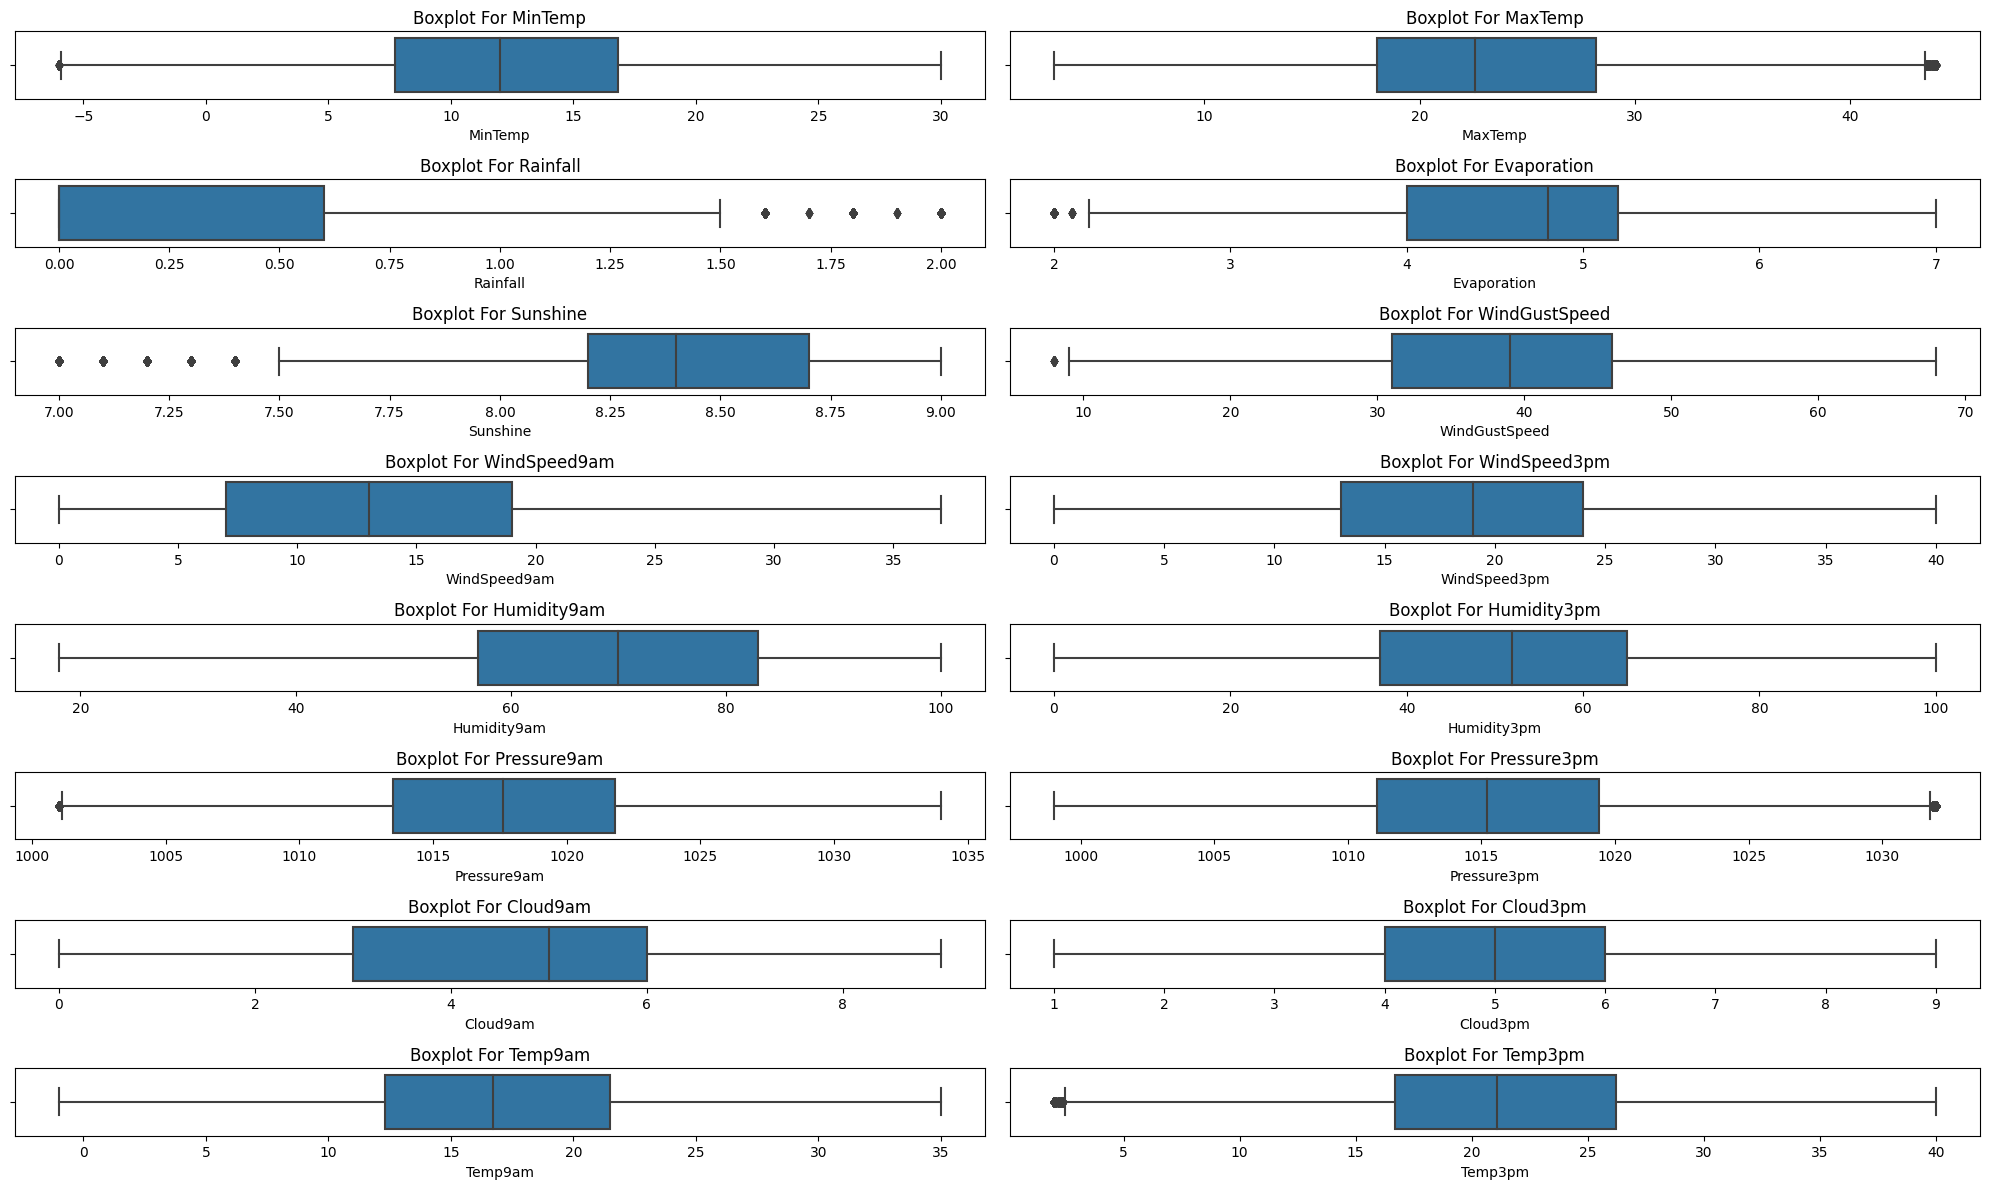

In [28]:
plt.figure(figsize=(20,12 ))
for n in num_cols:
  plt.subplot(8,2,num_cols.index(n)+1)
  sns.boxplot(x=n,data=data,hue='RainTomorrow')
  plt.title(f'Boxplot For {n}')
plt.tight_layout()
plt.show()

### **Applying Logistic Regression**

In [29]:
x = data.drop(['RainTomorrow','Date','Year','Month','Day'], axis=1)
y = data['RainTomorrow']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=20, random_state=42)

In [31]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [32]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [33]:
#Making prediction on the test data
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [34]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 85.0%
Classification Report :               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.50      0.67         6

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20



#### **Applying XGBoost Classifier**

In [35]:
x = data.drop(['RainTomorrow','Date','Year','Month','Day'], axis=1)
y = data['RainTomorrow']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=20, random_state=42)

In [36]:
xg = xgb.XGBClassifier(random_state=42)
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [37]:
y_pred = xg.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [38]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 85.0%
Classification Report :               precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.80      0.67      0.73         6

    accuracy                           0.85        20
   macro avg       0.83      0.80      0.81        20
weighted avg       0.85      0.85      0.85        20



#### **Applying Random Forest Classifier**

In [39]:
x = data.drop(['RainTomorrow','Date','Year','Month','Day'], axis=1)
y = data['RainTomorrow']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=20, random_state=42)

In [40]:
rfc = RandomForestClassifier(n_estimators = 100, random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred = rfc.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [42]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 75.0%
Classification Report :               precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.60      0.50      0.55         6

    accuracy                           0.75        20
   macro avg       0.70      0.68      0.69        20
weighted avg       0.74      0.75      0.74        20



#### **Applying Decision Tree**

In [43]:
x = data.drop(['RainTomorrow','Date','Year','Month','Day'], axis=1)
y = data['RainTomorrow']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [44]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [45]:
y_pred_dt = dt.predict(x_test)
y_pred_dt

array([0, 0, 0, ..., 0, 1, 0])

In [46]:
accuracy = accuracy_score(y_test,y_pred_dt)
report = classification_report(y_test,y_pred_dt)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 78.45112058297813%
Classification Report :               precision    recall  f1-score   support

           0       0.86      0.86      0.86     22672
           1       0.51      0.52      0.52      6420

    accuracy                           0.78     29092
   macro avg       0.69      0.69      0.69     29092
weighted avg       0.79      0.78      0.79     29092



## **Feature Selection**

#### Univariate Feature Selection

In [47]:
#Univariate feature selection using mutual information
from sklearn.feature_selection import mutual_info_classif

num = 10
selector = SelectKBest(score_func=mutual_info_classif, k=num)
X_new = selector.fit_transform(x, y)


#indices of the selected features
indices = selector.get_support(indices=True)

#Selected Features names
features_names = x.columns[indices]

print('Selected Features : ',features_names)

Selected Features :  Index(['Rainfall', 'Sunshine', 'WindGustSpeed', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'RainToday'],
      dtype='object')


In [48]:
x = data[['Rainfall', 'Sunshine', 'WindGustSpeed', 'Humidity9am', 'Humidity3pm','Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'RainToday']]
y = data['RainTomorrow']

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=20, random_state=42)

#### **Logistic Regression after Feature Selection**

In [50]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [51]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [52]:
#Making prediction on the test data
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [53]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 85.0%
Classification Report :               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.50      0.67         6

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20



#### **XGBoost Classifier after feature selection**

In [54]:
xg = xgb.XGBClassifier(random_state=42)
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [55]:
#Making prediction on the test data
y_pred = xg.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [56]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 85.0%
Classification Report :               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.50      0.67         6

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20



#### **Random Forest Classifier after feature selection**

In [57]:
rfc = RandomForestClassifier(n_estimators = 100, random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred = rfc.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [59]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 80.0%
Classification Report :               precision    recall  f1-score   support

           0       0.81      0.93      0.87        14
           1       0.75      0.50      0.60         6

    accuracy                           0.80        20
   macro avg       0.78      0.71      0.73        20
weighted avg       0.79      0.80      0.79        20



#### **Decision Tree after feature selection**

In [60]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [61]:
y_pred = dt.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1])

In [62]:
accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f'Accuracy : {accuracy*100}%')
print(f'Classification Report : {report}')

Accuracy : 80.0%
Classification Report :               precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.62      0.83      0.71         6

    accuracy                           0.80        20
   macro avg       0.77      0.81      0.78        20
weighted avg       0.83      0.80      0.81        20



## **Correlation Analysis**

#### Heatmap

<Axes: >

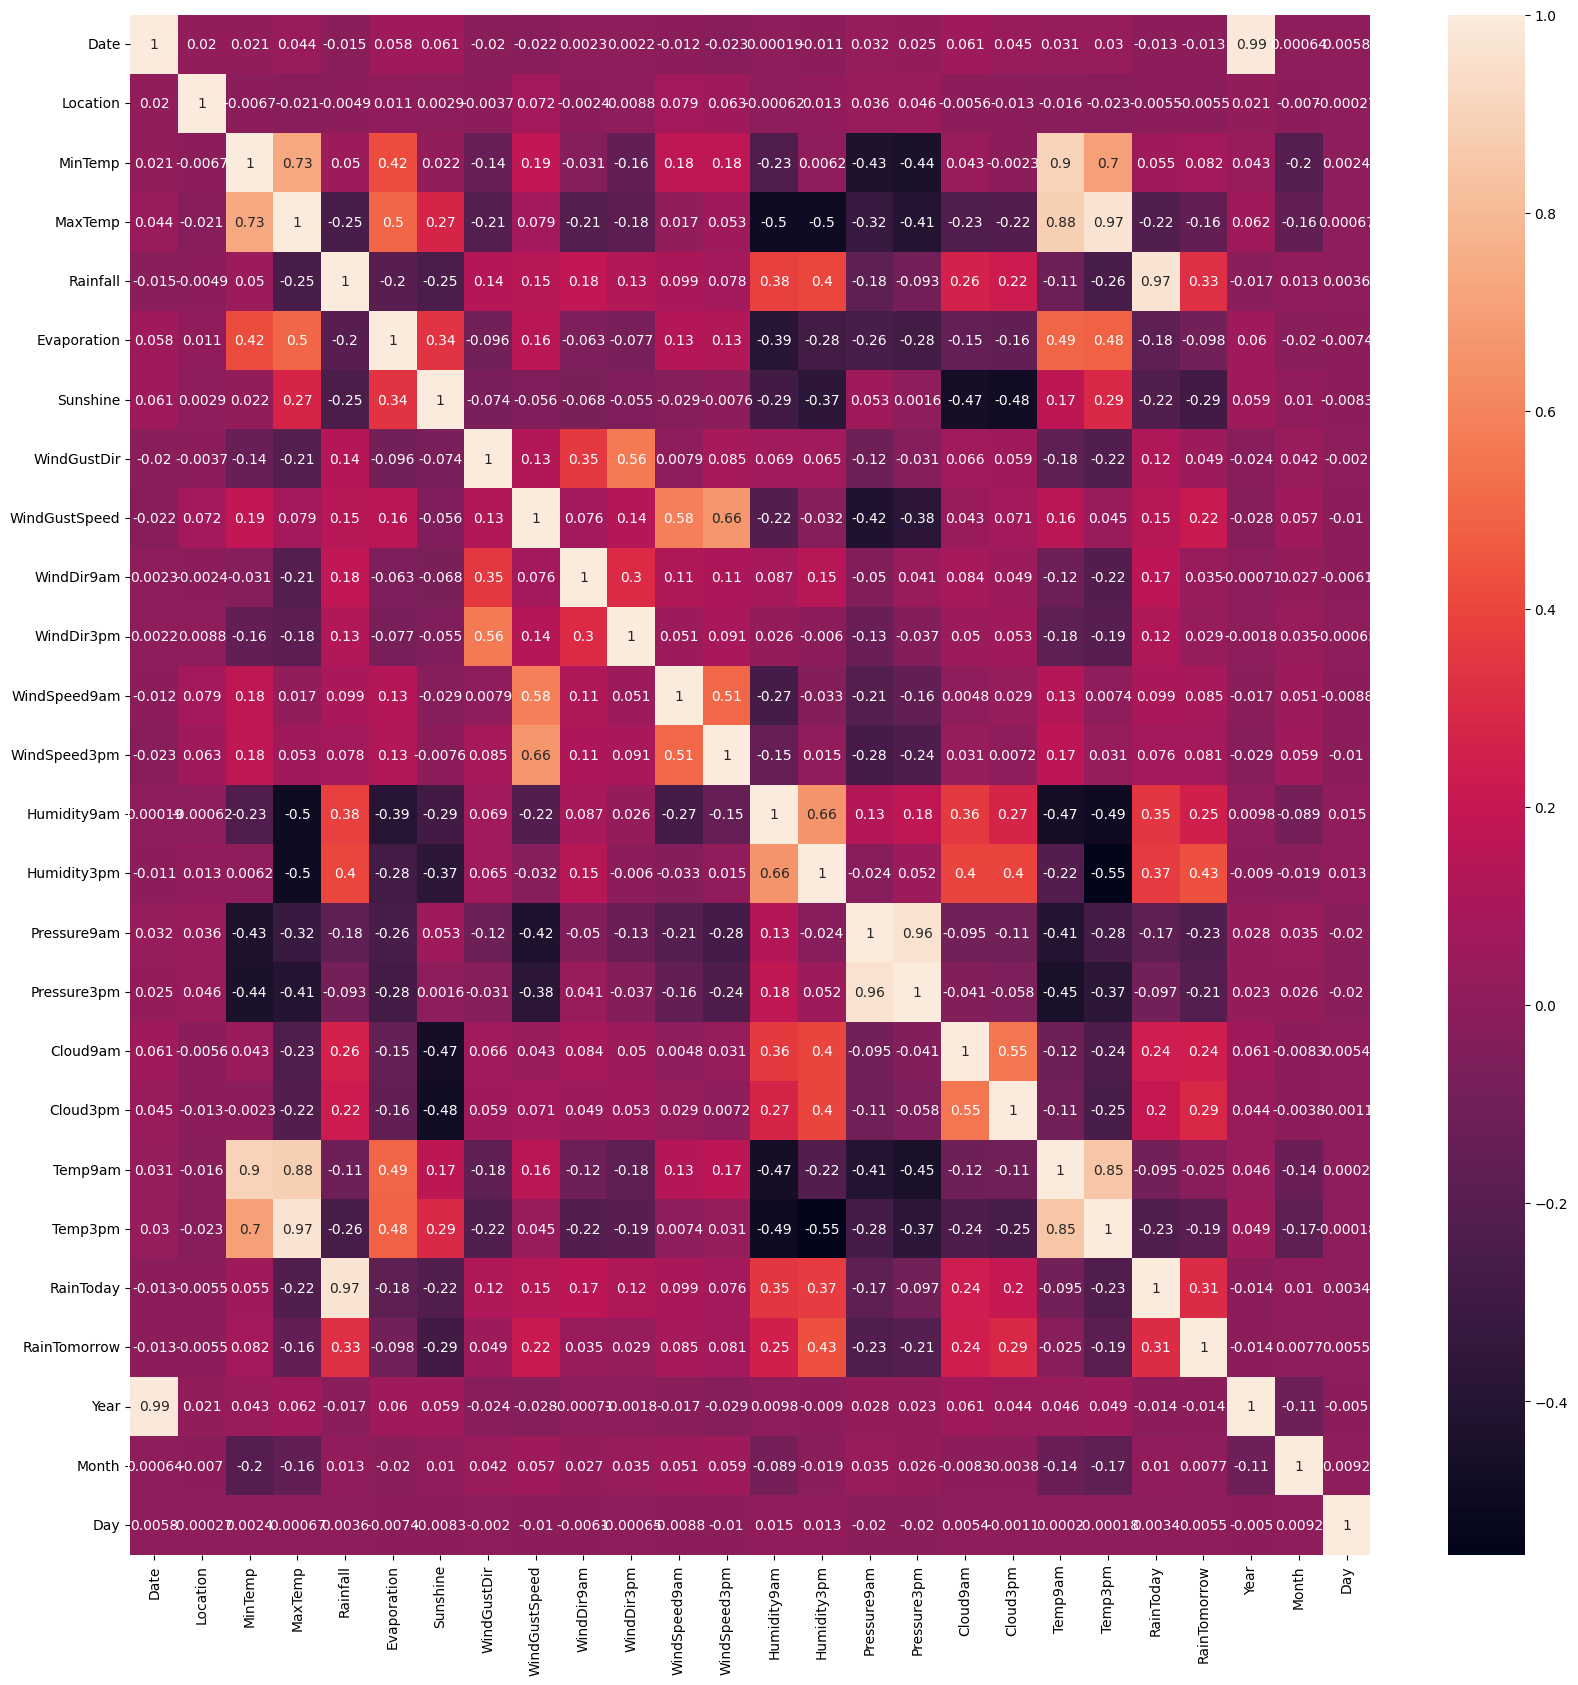

In [63]:
corrMat = data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrMat,annot=True)